**Install packages**

In [ ]:
!pip install -q keras-nlp keras-hub datasets scikit-learn

**Install packages**

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
import keras
import keras_hub
import keras_nlp
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)


from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix

**Load dataset**

In [ ]:
dataset = load_dataset("TimSchopf/medical_abstracts")

train_data = dataset["train"]
test_data = dataset["test"]

train_texts = list(train_data["medical_abstract"])
train_labels = list(train_data["condition_label"])

test_texts = list(test_data["medical_abstract"])
test_labels = list(test_data["condition_label"])

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))
print(type(train_texts), type(train_labels))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train size: 11550
Test size: 2888
<class 'list'> <class 'list'>


Inspect example

In [ ]:
print(train_texts[0])
print("Label:", train_labels[0])

Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2 activity paralleled the roentgenographic appearance of loosening and the technetium images and observations made at the time of revision surgery. The correlation between clinical, roentgenographic, histologic, and biochemical loosening indicates that the canine model is suitable for investigating the mechanisms of prosthetic failure. A canine model permits the study of possible nonsurgical therapeutic interventions with the ult

**Define label names**

In [ ]:
label_names = [
    "Neoplasms",
    "Digestive System Diseases",
    "Nervous System Diseases",
    "Cardiovascular Diseases",
    "General Pathological Conditions"
]

**Create BERT preprocessor**

In [ ]:
preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=256
)

**Build BERT classifier**

In [ ]:
classifier = keras_hub.models.BertTextClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=5,
    preprocessor=preprocessor
)

**Show model summary**

In [ ]:
classifier.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 768), (None,      │     109,482,240 │ padding_mask[0][0],        │
│                               │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 5)                 │           3,845 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 109,486,085 (417.66 MB)

 Trainable params: 109,486,085 (417.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Inspect preprocessor output

tokenized_input = classifier.preprocessor(train_texts[:2])
tokenized_input

{'token_ids': <tf.Tensor: shape=(2, 256), dtype=int32, numpy=
 array([[  101,  8153,  3431,  2105,  6065,  4013,  3367, 15689,  2229,
          1012,  1037, 28735,  2944,  2000,  8556,  1996,  3896,  1997,
          2019,  3424,  2378, 10258,  3286, 18900, 10253,  4005,  1012,
          1996,  2004, 23606, 15004, 22456,  4013,  3367, 24124,  3024,
          1037,  2965,  2005, 11538,  1996,  1999, 24269,  1998,  1999,
         25714,  4023,  1997,  1996,  4442,  3378,  2007,  1996, 29476,
          2075,  2832,  1999,  2698,  6077,  1012,  1996,  4442,  2020,
          7275,  1998,  5224,  1999,  3226,  2005,  7182,  6993,  1997,
          2051,  2061,  2008,  2037, 16012, 27179,  4023,  2071,  2022,
          3273,  2004,  2092,  2004,  1996,  3466,  1997,  2367,  6074,
          2794,  2000,  1996,  4442,  1999, 24269,  2030,  1999, 25714,
          1012,  1996, 16012, 27179,  3433,  2004,  4340,  2011,  6970,
          2571, 14228,  2078,  1011,  1015,  1998,  4013,  9153, 23296,
  

In [ ]:
# Inspect backbone output

backbone_output = classifier.backbone.predict(tokenized_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


**Compile model**

In [ ]:
classifier.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

**Train model**

In [ ]:
print(min(train_labels), max(train_labels))
print(sorted(set(train_labels)))

1 5
[1, 2, 3, 4, 5]


In [ ]:
split_dataset = train_data.train_test_split(test_size=0.1, seed=42)

train_split = split_dataset["train"]
val_split = split_dataset["test"]

train_texts = list(train_split["medical_abstract"])
train_labels = [x - 1 for x in train_split["condition_label"]]

val_texts = list(val_split["medical_abstract"])
val_labels = [x - 1 for x in val_split["condition_label"]]

test_texts = list(test_data["medical_abstract"])
test_labels = [x - 1 for x in test_data["condition_label"]]

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = dict(zip(classes, class_weights))
print(class_weights)

{np.int64(0): np.float64(0.9114423498465585), np.int64(1): np.float64(1.9429906542056075), np.int64(2): np.float64(1.5087082728592163), np.int64(3): np.float64(0.9420027186225646), np.int64(4): np.float64(0.601040763226366)}


In [ ]:
history = classifier.fit(
    train_texts,
    train_labels,
    validation_data=(val_texts, val_labels),
    batch_size=4,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 683s 233ms/step - accuracy: 0.4887 - loss: 1.1807 - val_accuracy: 0.5541 - val_loss: 1.1097
Epoch 2/5
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 576s 221ms/step - accuracy: 0.5794 - loss: 0.9529 - val_accuracy: 0.5714 - val_loss: 1.0656
Epoch 3/5
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 575s 221ms/step - accuracy: 0.6274 - loss: 0.8258 - val_accuracy: 0.5792 - val_loss: 1.0907
Epoch 4/5
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 573s 220ms/step - accuracy: 0.6499 - loss: 0.7534 - val_accuracy: 0.5671 - val_loss: 1.0580
Epoch 5/5
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 571s 220ms/step - accuracy: 0.6851 - loss: 0.6811 - val_accuracy: 0.5835 - val_loss: 1.0924


**Evaluate on test set**

In [ ]:
test_loss, test_acc = classifier.evaluate(test_texts, test_labels)

print(f"Test accuracy: {test_acc:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 522ms/step - accuracy: 0.5997 - loss: 1.0402
Test accuracy: 0.5997


**Predict**

In [ ]:
pred_logits = classifier.predict(test_texts)

pred_labels = np.argmax(pred_logits, axis=1)

91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 514ms/step


**Classification report**

In [ ]:
print(classification_report(
    test_labels,
    pred_labels,
    target_names=label_names
))

                                 precision    recall  f1-score   support

                      Neoplasms       0.69      0.72      0.70       633
      Digestive System Diseases       0.52      0.67      0.58       299
        Nervous System Diseases       0.49      0.73      0.59       385
        Cardiovascular Diseases       0.62      0.84      0.72       610
General Pathological Conditions       0.64      0.30      0.41       961

                       accuracy                           0.60      2888
                      macro avg       0.59      0.65      0.60      2888
                   weighted avg       0.61      0.60      0.58      2888



**Confusion matrix**

In [ ]:
cm = confusion_matrix(test_labels, pred_labels)

print(cm)

[[453  50  74  12  44]
 [ 33 199  17  11  39]
 [ 16   4 280  54  31]
 [ 19   7  23 515  46]
 [138 126 175 237 285]]


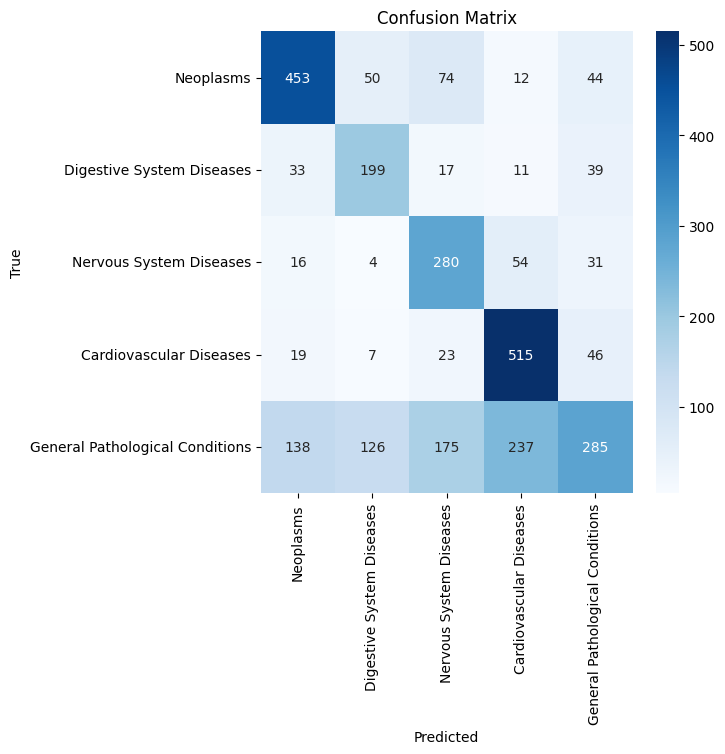

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Bert Confusion Matrix")
plt.show()

The confusion matrix reveals that the model performs well on specific disease categories such as Neoplasms and Cardiovascular Diseases, where domain-specific terminology is distinctive. However, the class "General Pathological Conditions" shows substantially lower recall compared to other categories. Many abstracts from this class are misclassified as Cardiovascular Diseases, Nervous System Diseases, or Neoplasms, indicating significant vocabulary overlap with other disease-specific categories. This suggests that the ambiguity and heterogeneous nature of this class make it inherently difficult to distinguish using text-based features.